## Implementation

The Variational Autoencoder will now be implemented and its performance assessed using the MNIST digits and Fashion MNIST datasets.

In [ ]:
# Standard library
import random
from collections import defaultdict
from typing import Tuple, Dict, Optional, Callable, Union

# Third party: numerics, deep learning, vision, plotting
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

# All modules below use this device string for .to(...)
ACCELERATOR = 'cuda:0'

# Original notebook asserts CUDA when ACCELERATOR is not a cuda:* string
if 'cuda' not in ACCELERATOR:
    assert torch.cuda.is_available()


### Dataset

The Torchvision library provides access to the MNIST digits and Fashion MNIST datasets. For further processing, these datasets will be enveloped with transformations such as:
- Conversion from PIL image to torch tensor
- Standardization

The estimated mean for the MNIST dataset is 0.13, and the standard deviation is 0.31. These estimates can be readily verified by computing the mean and std across all pixels in the training dataset.

In [ ]:
# MNIST-scale normalization (single channel); Fashion-MNIST uses same stats in practice
MNIST_MEAN = 0.13
MNIST_STD = 0.31

def standardize_transform(x: torch.Tensor) -> torch.Tensor:
    """
    Standardizes a given tensor using the precomputed MNIST mean and standard deviation.

    Args:
        x: Input tensor to standardize.

    Returns:
        Standardized tensor.
    """
    return (x - MNIST_MEAN) / MNIST_STD


def standardize_inverse(x: torch.Tensor) -> torch.Tensor:
    """
    Reverses the standardization on a tensor using the precomputed MNIST mean and standard deviation.

    Args:
        x: Input tensor to de-standardize.

    Returns:
        De-standardized tensor.
    """
    return x * MNIST_STD + MNIST_MEAN


class UnsupervisedMNIST(Dataset):
    """
    A class that wraps the MNIST dataset for unsupervised learning. It allows to work with either the Fashion MNIST
    or the original MNIST dataset. This dataset will be used for the Autoencoder and VAE training (in the unsupervised manner).
    """
    def __init__(self, train: bool = True, fashion: bool = False):
        """
        Initializes the dataset object, downloads the dataset and prepares the transform.

        Args:
            train: Whether to load the training split (True) or the test split (False).
            fashion: Whether to load the Fashion MNIST dataset (True) or the original MNIST dataset (False).
        """
        cls = torchvision.datasets.FashionMNIST if fashion else torchvision.datasets.MNIST
        self._mnist = cls(root='/tmp/mnist', train=train, download=True)
        self._to_tensor = transforms.ToTensor()
        print("print::::minist" , type(self._mnist))  # debug: which torchvision class was constructed

    def __getitem__(self, i: int) -> Tuple[torch.Tensor, torch.Tensor]:
        raw_img, _ = self._mnist[i]  # discard label: reconstruction-only training
        img = self._to_tensor(raw_img)  # [0,1] float, shape (1, H, W)
        return standardize_transform(img)

    def __len__(self) -> int:
        return len(self._mnist)

    def label(self, i: int) -> int:
        """
        Returns the label of an image in the dataset at a given index.
        This is only required for the future visualizations.

        Args:
            i: The index of the image for which to return the label.

        Returns:
            The label of the image at the given index.
        """
        return self._mnist[i][1]

    @staticmethod
    def postprocess_image(img: torch.Tensor) -> np.ndarray:
        """
        Performs inverse operation to the data preprocessing. Used for model output inverse.

        Args:
            img: Raw img output

        Returns:
            Postprocessed image.
        """
        img = img.detach().cpu()
        img = standardize_inverse(img)
        img = torch.clip(img, min=0.0, max=1.0)  # keep in valid image range before uint8
        img = img * 255
        img = img.numpy().astype(np.uint8)
        img = img[0]  # drop channel dim for grayscale imshow (H, W)
        return img


mnist_example = UnsupervisedMNIST(train=True)
mnist_example[0].shape, mnist_example.label(0)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


(torch.Size([1, 28, 28]), 5)

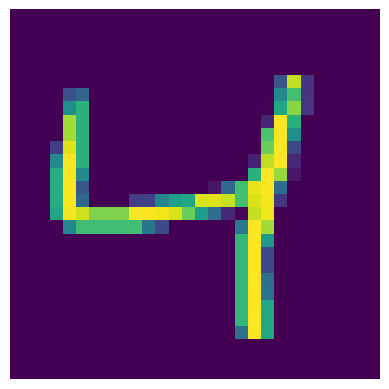

In [ ]:
# Display helper: tensor postprocessing is dataset-specific (see UnsupervisedMNIST.postprocess_image)
def show_image(img: np.ndarray, ax: Optional[plt.Axes] = None) -> None:
    """
    Plots an image.

    Args:
        img: Raw numpy image
        ax: Matplotlib ax (optional)
    """
    if ax is not None:
        ax.imshow(img)
        ax.axis('off')
    else:
        plt.imshow(img)
        plt.axis('off')

show_image(UnsupervisedMNIST.postprocess_image(mnist_example[2]))


### Implementation of the AutoEncoder neural network model

In this section, an Autoencoder neural network is assembled. This is followed by the development of a Variational Autoencoder, which employs a similar structure. Although a latent space of two dimensions may not accurately represent the entirety of the MNIST dataset, it is utilized here for the simplicity of visualization.

In [3]:
class AutoEncoder(nn.Module):
    """
    Implementation of AutoEncoder (MLP).
    MLP might be more efficient than CNN for very shallow networks (just like in this case).
    """
    def __init__(self, latent_dim: int = 2):
        """
        Args:
            latent_dim: Latent dimension
        """
        super().__init__()

        # Encoder: image -> low-dim code z (deterministic)
        # Expects input shape 1x28x28
        self._encoder = nn.Sequential(
            nn.Flatten(start_dim=-3),  # 28*28 = 784
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Linear(196, latent_dim)
        )

        # Decoder: z -> flattened image -> reshaped to 1x28x28
        self._decoder = nn.Sequential(
            nn.Linear(latent_dim, 196),
            nn.ReLU(),
            nn.Linear(196, 392),
            nn.ReLU(),
            nn.Linear(392, 784),
            nn.Unflatten(-1, (1, 28, 28))
        )

    def show_encoder_transforms(self, x: torch.Tensor) -> None:
        """
        Prints list of encoder layers and output shapes. Useful for debugging and model validation.

        Args:
            x: Random input (with shape 1, 28, 28)
        """
        print('---Encoder transforms---')
        print(f'Input shape: {x.shape}')
        for i, layer in enumerate(self._encoder):
            layer_name = type(layer).__name__
            x = layer(x)
            print(f'[{i+1}] name={layer_name}, shape={x.shape}')

    def show_decoder_transforms(self, x: torch.Tensor) -> None:
        """
        Prints list of decoder layers and output shapes. Useful for debugging and model validation.

        Args:
            x: Latent vector (shape (latent_dim,))
        """
        print('---Decoder transforms---')
        print(f'[0] Input shape: {x.shape}')
        for i, layer in enumerate(self._decoder):
            layer_name = type(layer).__name__
            x = layer(x)
            print(f'[{i+1}] name={layer_name}, shape={x.shape}')
        print()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = self._encoder(x)
        x_hat = self._decoder(z)
        return x_hat, z


ae = AutoEncoder()
ae.show_encoder_transforms(torch.randn(1, 28, 28, dtype=torch.float32))
ae.show_decoder_transforms(torch.randn(2, dtype=torch.float32))


---Encoder transforms---
Input shape: torch.Size([1, 28, 28])
[1] name=Flatten, shape=torch.Size([784])
[2] name=Linear, shape=torch.Size([392])
[3] name=ReLU, shape=torch.Size([392])
[4] name=Linear, shape=torch.Size([196])
[5] name=ReLU, shape=torch.Size([196])
[6] name=Linear, shape=torch.Size([2])
---Decoder transforms---
[0] Input shape: torch.Size([2])
[1] name=Linear, shape=torch.Size([196])
[2] name=ReLU, shape=torch.Size([196])
[3] name=Linear, shape=torch.Size([392])
[4] name=ReLU, shape=torch.Size([392])
[5] name=Linear, shape=torch.Size([784])
[6] name=Unflatten, shape=torch.Size([1, 28, 28])



#### Training Autoencoder

In [ ]:
# Deterministic autoencoder training: minimize pixel-wise MSE between x and reconstruction.

def train_autoencoder(
    model: AutoEncoder,
    train_dataset: Dataset,
    val_dataset: Dataset,
    epochs: int = 30,
    scheduler_step_size: int = 15,
    batch_size: int = 64,
    num_workers = 2,
    accelerator: str = 'cpu'
) -> dict:
    """
    Trains the AutoEncoder model on the provided datasets for a specified number of epochs.

    Args:
        model: An instance of AutoEncoder that will be trained.
        train_dataset: The dataset object used for training.
        val_dataset: The dataset object used for validation.
        epochs: The number of epochs to train the model. Defaults to 20.
        scheduler_step_size: Step size for learning rate scheduler. Defaults to 10.
        batch_size: The size of the batches for training and validation. Defaults to 64.
        num_workers: Number of workers for data loading. Defaults to 2.
        accelerator: The device on which to train the model. Defaults to 'cpu'.

    Returns:
        A dictionary containing the model's training and validation losses.
    """
    # Define the loss function (Mean Squared Error for Autoencoders)
    loss_func = nn.MSELoss()
    # Move the model to the specified accelerator (CPU or GPU)
    model.to(accelerator)
    # Initialize the Adam optimizer with a learning rate of 1e-3
    optimizer = torch.optim.Adam(lr=1e-3, params=model.parameters())
    # Initialize a learning rate scheduler to decrease LR every `scheduler_step_size` epochs
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = scheduler_step_size)

    # Create DataLoaders for training and validation datasets
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers)
    val_dataloader = DataLoader(val_dataset, batch_size, num_workers=num_workers, shuffle=True)

    # Dictionary to store training history (losses per epoch)
    history = defaultdict(list)

    # Main training loop over the specified number of epochs
    for epoch in tqdm(range(1, epochs+1)):
        total_loss = 0.0
        n_steps = 0

        # Set the model to training mode
        model.train()
        # Iterate over batches in the training dataloader
        for img in train_dataloader:
            # Zero out gradients from the previous iteration
            optimizer.zero_grad()

            # Move the input image to the accelerator device
            img = img.to(accelerator)
            # Perform a forward pass to reconstruct the image
            reconstructed_img, _ = model(img)

            # Calculate the reconstruction loss
            loss = loss_func(img, reconstructed_img)
            # Perform backpropagation to compute gradients
            loss.backward()
            # Update model parameters using the optimizer
            optimizer.step()

            # Accumulate training loss
            total_loss += loss.detach().cpu().item()
            n_steps += 1

        # Step the learning rate scheduler
        scheduler.step()

        # Calculate average training loss for the epoch
        train_loss = total_loss / n_steps

        # Reset accumulators for validation loss
        total_loss = 0.0
        n_steps = 0

        # Set the model to evaluation mode (disables dropout, batchnorm updates, etc.)
        model.eval()
        # Disable gradient calculations for validation to save memory and computation
        with torch.no_grad():
            # Iterate over batches in the validation dataloader
            for img in val_dataloader:
                # Move the input image to the accelerator device
                img = img.to(accelerator)
                # Perform a forward pass to reconstruct the image
                reconstructed_img, _ = model(img)

                # Calculate the validation loss
                loss = loss_func(img, reconstructed_img)

                # Accumulate validation loss
                total_loss += loss.detach().cpu().item()
                n_steps += 1

        # Calculate average validation loss for the epoch
        val_loss = total_loss / n_steps

        # Print epoch-wise training and validation losses
        print(f'[Epoch={epoch:02d}]: train_loss={train_loss:.2f}, val_loss={val_loss:.2f}')

        # Store losses in history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch'].append(epoch)

    return dict(history)


autoencoder = AutoEncoder()
history = train_autoencoder(
    model=autoencoder,
    train_dataset=UnsupervisedMNIST(train=True),
    val_dataset=UnsupervisedMNIST(train=False),
    accelerator=ACCELERATOR
)

#### Autoencoder demonstration

In this section autoencoder reconstruction and latent space will be showcased.

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


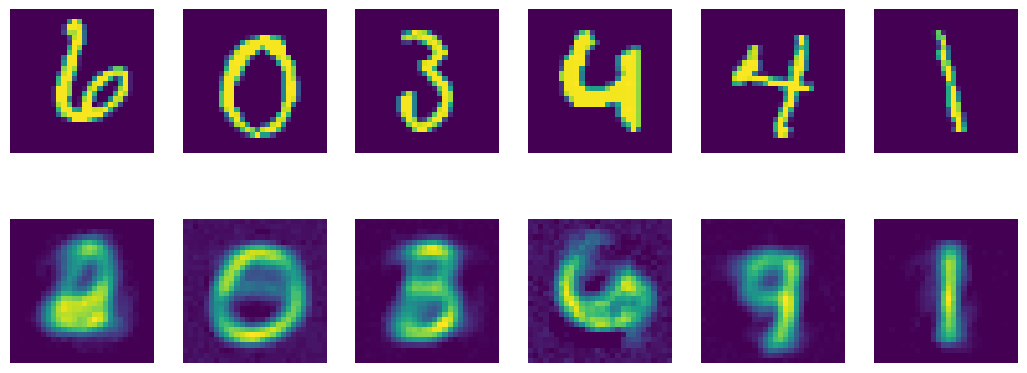

In [9]:
@torch.no_grad()
def show_naive_autoencoder_error_analysis_visualization(
    model: AutoEncoder,
    val_dataset: Dataset,
    postprocess_image: Callable[[torch.Tensor], np.ndarray],
    accelerator: str = 'cpu'
) -> None:
    """
    Displays a naive visualization for error analysis of an autoencoder.

    This function generates and displays a visual comparison of original and reconstructed
    images using a trained autoencoder model. The error analysis is considered naive because
    it only visually inspects a small percentage of the individual reconstruction errors.

    Args:
        model: The trained autoencoder model to use for image reconstruction.
        val_dataset: The dataset to use for generating the visualization. Typically,
            this should be a validation or test dataset.
        postprocess_image: Transforms raw model output to an image
        accelerator: The device to perform operations. Default is 'cpu'.
            Options are 'cpu' or 'cuda' if GPU is available.
    """
    N_SAMPLES = 6  # random test indices — qualitative check only
    indices = list(range(len(val_dataset)))
    sampled_indices = random.choices(indices, k=N_SAMPLES)
    model.to(accelerator)

    # Top row: originals; bottom row: reconstructions
    _, axs = plt.subplots(figsize=(2 * N_SAMPLES + 1, 5), nrows=2, ncols=N_SAMPLES)
    for i in range(N_SAMPLES):
        index = sampled_indices[i]
        img = val_dataset[index]
        img = img.to(accelerator)
        img_hat, _ = model.forward(img)
        img, img_hat = [postprocess_image(v) for v in [img, img_hat]]

        show_image(img, ax=axs[0][i])
        show_image(img_hat, ax=axs[1][i])

    plt.show()

show_naive_autoencoder_error_analysis_visualization(
    model=autoencoder,
    val_dataset=UnsupervisedMNIST(train=False),
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


The model appears to reconstruct the images reasonably well, though a certain level of blurriness is evident. Improvements in image sharpness might be achieved by expanding the latent dimension space (e.g. `latent_dim=8`).

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


  0%|          | 0/10000 [00:00<?, ?it/s]

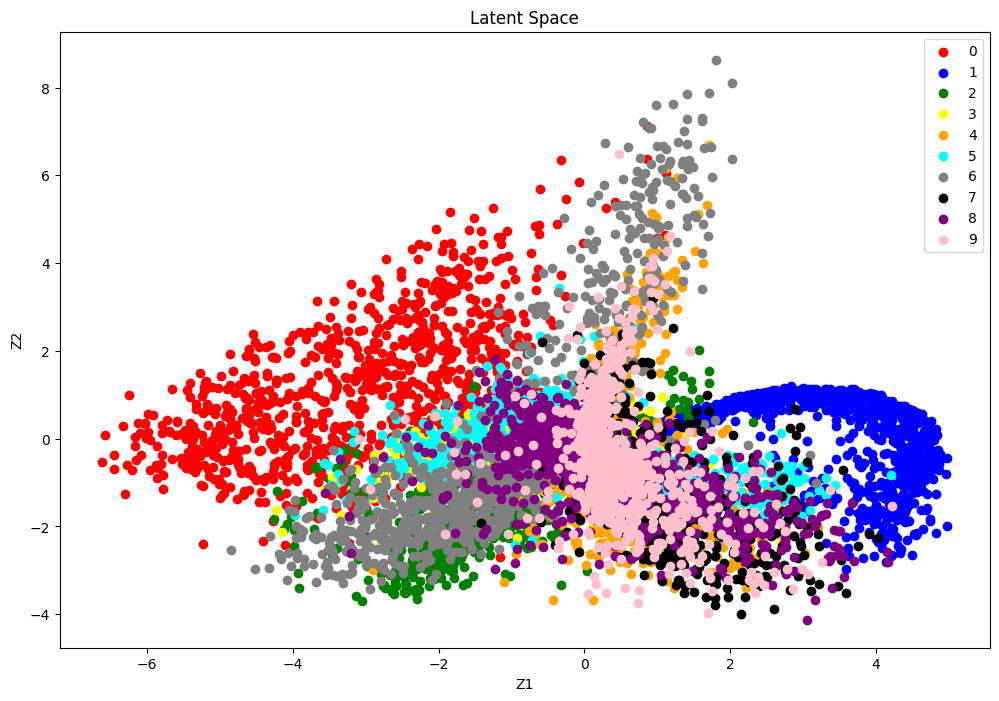

In [10]:
@torch.no_grad()
def show_ae_latent_space_distribution_visualization(
    model: AutoEncoder,
    val_dataset: Dataset,
    accelerator: str = 'cpu'
) -> None:
    """
    Displays the distribution of data in the Autoencoder' latent space.

    Args:
        model: The autoencoder model.
        val_dataset: Dataset used for the visualization.
        accelerator: The device for calculations ('cpu' or 'cuda').
    """
    COLORS = ['red', 'blue', 'green', 'yellow', 'orange', 'cyan', 'gray', 'black', 'purple', 'pink']
    model.eval()
    model.to(accelerator)

    # Collect 2-D latent codes per class label for scatter plot
    zs = defaultdict(list)
    for i in tqdm(range(len(val_dataset))):
        img = val_dataset[i].to(accelerator)
        label = val_dataset.label(i)
        _, z = model(img)  # use passed-in model (2-D bottleneck)

        zs[label].append(z.detach().cpu())

    zs = {k: torch.stack(v) for k, v in zs.items()}
    zs = dict(sorted(zs.items()))
    plt.figure(figsize=(12, 8))
    for i, (label, z) in enumerate(zs.items()):
        z = z.numpy()
        plt.scatter(z[:, 0], z[:, 1], color=COLORS[i], label=str(label))

    plt.legend()
    plt.title('Latent Space')
    plt.xlabel('Z1')
    plt.ylabel('Z2')
    plt.show()

show_ae_latent_space_distribution_visualization(
    model=autoencoder,
    val_dataset=UnsupervisedMNIST(train=False),
    accelerator=ACCELERATOR
)


The overlapping class clusters and extensive spread in the latent space suggest potential underfitting of the model. Expanding the latent dimension could potentially result in better separation of clusters. However, this is not necessarily true for VAEs, where the KL component of the ELBO loss constrains clusters to be closer to the center.

## Variational Autoencoder

In this segment, the implementation of the Variational Autoencoder (VAE) model is carried out. Notably, the VAE model retains all capabilities of the Autoencoder (AE) model while also offering additional features such as:

- generating fresh images by sampling from the prior;
- creating new images influenced by an input, by sampling from the posterior;
- performing interpolation over the latent space.

In [11]:
class VariationalAutoEncoder(nn.Module):
    """
    Abstract VAE: inject encoder/decoder that map pixels <-> latent Gaussian parameters.
    Subclasses (MLP / CNN) define architecture; this class wires the ELBO forward pass.
    """
    def __init__(self, encoder: nn.Module, decoder: nn.Module):
        """
        Args:
            encoder: Maps input to a 2*latent_dim vector (mean and log-variance of q(z|x)).
            decoder: Maps latent z back to image space (likelihood mean).
        """
        super().__init__()
        self._encoder = encoder
        self._decoder = decoder

    def show_encoder_transforms(self, x: torch.Tensor) -> None:
        """
        Prints list of encoder layers and output shapes. Useful for debugging and model validation.

        Args:
            x: Random input (with shape 1, 28, 28)
        """
        print('---Encoder transforms---')
        print(f'Input shape: {x.shape}')
        for i, layer in enumerate(self._encoder):
            layer_name = type(layer).__name__
            x = layer(x)
            print(f'[{i+1}] name={layer_name}, shape={x.shape}')

    def show_decoder_transforms(self, x: torch.Tensor) -> None:
        """
        Prints list of decoder layers and output shapes. Useful for debugging and model validation.

        Args:
            x: Latent vector input to the decoder (shape (latent_dim,)).
        """
        print('---Decoder transforms---')
        print(f'[0] Input shape: {x.shape}')
        for i, layer in enumerate(self._decoder):
            layer_name = type(layer).__name__
            x = layer(x)
            print(f'[{i+1}] name={layer_name}, shape={x.shape}')
        print()

    def forward(self, x: torch.Tensor, sample: bool = True) -> Dict[str, torch.Tensor]:
        # Encoder outputs [mu || log sigma^2] for factorized Gaussian q(z|x)
        z_all = self._encoder(x)
        z_mean, z_log_var = z_all[..., :self._latent_dim], z_all[..., self._latent_dim:]

        if sample:
            # Reparameterization trick: z = mu + sigma * eps, eps ~ N(0, I)
            z_std = torch.sqrt(torch.exp(z_log_var))
            e = torch.randn_like(z_mean)
            z = z_mean + z_std * e
        else:
            z = z_mean  # posterior mean — useful for stable plots / deterministic pass

        x_hat = self._decoder(z)
        return {
            'x': x_hat,
            'z': z,
            'z_mean': z_mean,
            'z_log_var': z_log_var
        }

    def sample_from_prior(self) -> torch.Tensor:
        """
        z ~ N(0, I), decode — unconditional generation from the VAE prior.

        Returns:
            Single-channel image tensor (no batch dim on return).
        """
        device = next(self.parameters()).device
        z = torch.randn(1, self._latent_dim).to(device)
        return self._decoder(z)[0]

    def sample_from_posterior(self, x_evidence: torch.Tensor) -> torch.Tensor:
        """
        One stochastic forward through q(z|x) then decode — diverse reconstructions for same x.

        Args:
            x_evidence: A single image tensor (C, H, W).

        Returns:
            Decoded image tensor without batch dimension.
        """
        x_evidence = x_evidence.unsqueeze(0)  # batch size 1
        output = self.forward(x_evidence, sample=True)
        return output['x'][0]


class MLPVariationalAutoEncoder(VariationalAutoEncoder):
    """
    Fully-connected VAE for small images (e.g. MNIST): encoder emits 2*latent_dim for mu and logvar.
    """
    def __init__(self, image_shape: Tuple[int, int, int] = (1, 28, 28), latent_dim: int = 2):
        """
        Args:
            image_shape: (C, H, W) for flatten/unflatten.
            latent_dim: Dimension of z; encoder last layer size is 2 * latent_dim.
        """
        image_flat_size = image_shape[0] * image_shape[1] * image_shape[2]

        encoder = nn.Sequential(
            nn.Flatten(start_dim=-3),
            nn.Linear(image_flat_size, 392),
            nn.ReLU(),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Linear(196, 2 * latent_dim)  # mu and log sigma^2
        )

        decoder = nn.Sequential(
            nn.Linear(latent_dim, 196),
            nn.ReLU(),
            nn.Linear(196, 392),
            nn.ReLU(),
            nn.Linear(392, image_flat_size),
            nn.Unflatten(-1, image_shape)
        )

        super().__init__(encoder=encoder, decoder=decoder)
        self._latent_dim = latent_dim


vae = MLPVariationalAutoEncoder()
vae.show_encoder_transforms(torch.randn(1, 28, 28, dtype=torch.float32))
vae.show_decoder_transforms(torch.randn(2, dtype=torch.float32))
output = vae(torch.randn(1, 28, 28, dtype=torch.float32))
{k: v.shape for k, v in output.items()}


---Encoder transforms---
Input shape: torch.Size([1, 28, 28])
[1] name=Flatten, shape=torch.Size([784])
[2] name=Linear, shape=torch.Size([392])
[3] name=ReLU, shape=torch.Size([392])
[4] name=Linear, shape=torch.Size([196])
[5] name=ReLU, shape=torch.Size([196])
[6] name=Linear, shape=torch.Size([4])
---Decoder transforms---
[0] Input shape: torch.Size([2])
[1] name=Linear, shape=torch.Size([196])
[2] name=ReLU, shape=torch.Size([196])
[3] name=Linear, shape=torch.Size([392])
[4] name=ReLU, shape=torch.Size([392])
[5] name=Linear, shape=torch.Size([784])
[6] name=Unflatten, shape=torch.Size([1, 28, 28])



{'x': torch.Size([1, 28, 28]),
 'z': torch.Size([2]),
 'z_mean': torch.Size([2]),
 'z_log_var': torch.Size([2])}

#### Training VAE

The training process for the VAE tends to be more time-consuming than for the AE due to its inherent stochastic nature.

In [15]:
class GaussianELBOLoss(nn.Module):
    """
    Scalar ELBO loss = reconstruction term + KL(q(z|x) || p(z)) with Gaussian p(z)=N(0,I).
    The likelihood term treats decoder output as mean of an isotropic Gaussian around x (variance ~ noise).
    """
    def __init__(self, noise: float):
        """
        Args:
            noise: Positive scalar controlling assumed observation noise (smaller -> tighter recon penalty).
        """
        super().__init__()
        self._noise = noise

    def forward(self, x_hat: torch.Tensor, x_target: torch.Tensor, z_mean: torch.Tensor, z_log_var: torch.Tensor) -> torch.Tensor:
        # Negative log-likelihood under Gaussian decoder (up to scale; mean over batch)
        likelihood_loss = torch.mean(1 / (2 * self._noise) * torch.sum(torch.square(x_hat - x_target), dim=-1))
        z_var = torch.exp(z_log_var)
        # KL for diagonal Gaussian q vs standard normal (closed form; implementation follows notebook formula)
        kl_loss = torch.mean(- 0.5 * torch.sum(1 + z_log_var / 2 - z_var - torch.square(z_mean), dim=-1))
        return likelihood_loss + kl_loss, likelihood_loss, kl_loss


In [ ]:
# VAE training: minimize ELBO = recon loss + KL; GaussianELBOLoss returns total + parts for logging.
def train_variational_autoencoder(
    model: VariationalAutoEncoder,
    train_dataset: Dataset,
    val_dataset: Dataset,
    vae_noise: float = 0.1,
    epochs: int = 40,
    base_learning_rate: float = 1e-3,
    scheduler_step_size: int = 20,
    batch_size: int = 64,
    num_workers = 2,
    accelerator: str = 'cpu'
) -> dict:
    """
    Trains the Variational AutoEncoder (VAE) model and returns the training history.

    Args:
        model: The VariationalAutoEncoder model to be trained.
        train_dataset: The dataset used for training.
        val_dataset: The dataset used for validation during training.
        vae_noise: VAE noise hyperparameter - higher value -> stronger regularization
        epochs: The number of epochs to train the model. Default is 20.
        base_learning_rate: Base (starting) learning rate
        scheduler_step_size: The number of epochs after which the scheduler decreases the learning rate. Default is 10.
        batch_size: The size of the batches used for training and validation. Default is 64.
        num_workers: The number of worker threads used with the DataLoader. Default is 2.
        accelerator: The device to perform operations. Default is 'cpu'. Options are 'cpu' or 'cuda' if GPU is available.

    Returns:
        A dictionary containing the training history, including training and validation loss per epoch.
    """
    loss_func = GaussianELBOLoss(noise=vae_noise)
    model.to(accelerator)
    optimizer = torch.optim.Adam(lr=base_learning_rate, params=model.parameters())
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = scheduler_step_size)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers)
    val_dataloader = DataLoader(val_dataset, batch_size, num_workers=num_workers, shuffle=True)

    history = defaultdict(list)

    for epoch in tqdm(range(1, epochs+1)):
        total_loss = 0.0
        total_likelihood_loss = 0.0
        total_kl_loss = 0.0
        n_steps = 0

        model.train()
        for img in train_dataloader:
            optimizer.zero_grad()
            img = img.to(accelerator)
            output = model(img)  # sample=True: reparameterized z for ELBO gradient

            loss, likelihood_loss, kl_loss = loss_func(output['x'], img, output['z_mean'], output['z_log_var'])
            loss.backward()
            optimizer.step()

            total_loss += loss.detach().cpu().item()
            total_likelihood_loss += likelihood_loss.detach().cpu().item()
            total_kl_loss += kl_loss.detach().cpu().item()
            n_steps += 1

        scheduler.step()

        train_loss = total_loss / n_steps
        train_likelihood_loss = total_likelihood_loss / n_steps
        train_kl_loss = total_kl_loss / n_steps

        total_loss = 0.0
        total_likelihood_loss = 0.0
        total_kl_loss = 0.0
        n_steps = 0

        model.eval()
        with torch.no_grad():
            for img in val_dataloader:
                img = img.to(accelerator)
                # Still uses sample=True by default; set model(..., sample=False) if you want deterministic z on val
                output = model(img)

                loss, likelihood_loss, kl_loss = loss_func(output['x'], img, output['z_mean'], output['z_log_var'])

                total_loss += loss.detach().cpu().item()
                total_likelihood_loss += likelihood_loss.detach().cpu().item()
                total_kl_loss += kl_loss.detach().cpu().item()
                n_steps += 1

        val_loss = total_loss / n_steps
        val_likelihood_loss = total_likelihood_loss / n_steps
        val_kl_loss = total_kl_loss / n_steps

        print(f'[Epoch={epoch:02d}]: train_loss={train_loss:.2f}, val_loss={val_loss:.2f}')

        history['train_loss'].append(train_loss)
        history['train_likelihood_loss'].append(train_likelihood_loss)
        history['train_kl_loss'].append(train_kl_loss)
        history['val_loss'].append(val_loss)
        history['val_likelihood_loss'].append(val_likelihood_loss)
        history['val_kl_loss'].append(val_kl_loss)
        history['epoch'].append(epoch)

    return dict(history)


vae = MLPVariationalAutoEncoder()
history = train_variational_autoencoder(
    model=vae,
    train_dataset=UnsupervisedMNIST(train=True),
    val_dataset=UnsupervisedMNIST(train=False),
    accelerator=ACCELERATOR
)


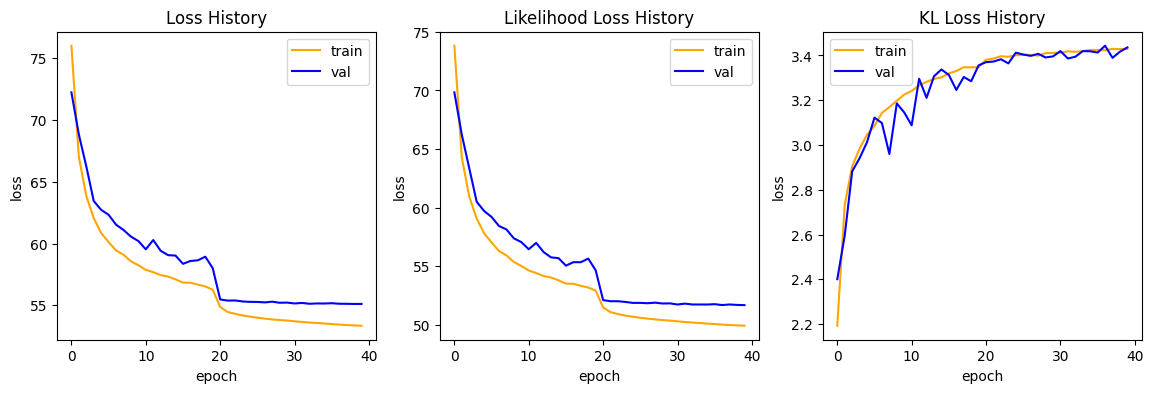

In [18]:
def show_vae_training_history(history: dict) -> None:
    """
    Displays the training history of the Variational Autoencoder (VAE) model.

    Args:
        history: A dictionary containing the training history.
    """

    _, axs = plt.subplots(figsize=(14, 4), ncols=3)
    # Left to right: total ELBO, reconstruction part, KL part
    axs[0].plot(history['train_loss'], color='orange', label='train')
    axs[0].plot(history['val_loss'], color='blue', label='val')
    axs[0].set_xlabel('epoch')
    axs[0].set_ylabel('loss')
    axs[0].set_title('Loss History')
    axs[0].legend()

    axs[1].plot(history['train_likelihood_loss'], color='orange', label='train')
    axs[1].plot(history['val_likelihood_loss'], color='blue', label='val')
    axs[1].set_xlabel('epoch')
    axs[1].set_ylabel('loss')
    axs[1].set_title('Likelihood Loss History')
    axs[1].legend()

    axs[2].plot(history['train_kl_loss'], color='orange', label='train')
    axs[2].plot(history['val_kl_loss'], color='blue', label='val')
    axs[2].set_xlabel('epoch')
    axs[2].set_ylabel('loss')
    axs[2].set_title('KL Loss History')
    axs[2].legend()

    plt.show()

show_vae_training_history(history)


#### VAE demonstration

##### Reconstruction

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


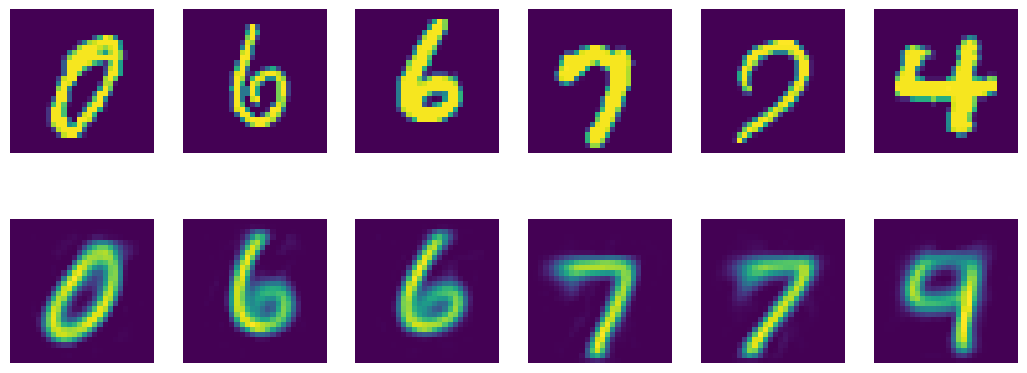

In [20]:
@torch.no_grad()
def show_naive_variational_autoencoder_error_analysis_visualization(
    model: VariationalAutoEncoder,
    val_dataset: Dataset,
    postprocess_image: Callable[[torch.Tensor], np.ndarray],
    accelerator: str = 'cpu'
) -> None:
    """
    Displays a naive visualization for error analysis of a VAE.

    Args:
        model: The trained VAE model to use for image reconstruction.
        val_dataset: The dataset to use for generating the visualization. Typically,
            this should be a validation or test dataset.
        postprocess_image: Transforms raw model output to an image.
        accelerator: The device to perform operations. Default is 'cpu'.
            Options are 'cpu' or 'cuda' if GPU is available.
    """
    N_SAMPLES = 6
    indices = list(range(len(val_dataset)))
    sampled_indices = random.choices(indices, k=N_SAMPLES)
    model.to(accelerator)

    _, axs = plt.subplots(figsize=(2 * N_SAMPLES + 1, 5), nrows=2, ncols=N_SAMPLES)
    for i in range(N_SAMPLES):
        index = sampled_indices[i]
        img = val_dataset[index]
        img = img.to(accelerator)
        output = model.forward(img)  # default: stochastic z, then decode to mean image
        img_hat = output['x']
        img, img_hat = [postprocess_image(v) for v in [img, img_hat]]

        show_image(img, ax=axs[0][i])
        show_image(img_hat, ax=axs[1][i])

    plt.show()

show_naive_variational_autoencoder_error_analysis_visualization(
    model=vae,
    val_dataset=UnsupervisedMNIST(train=False),
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


##### Latent space visualization

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


  0%|          | 0/10000 [00:00<?, ?it/s]

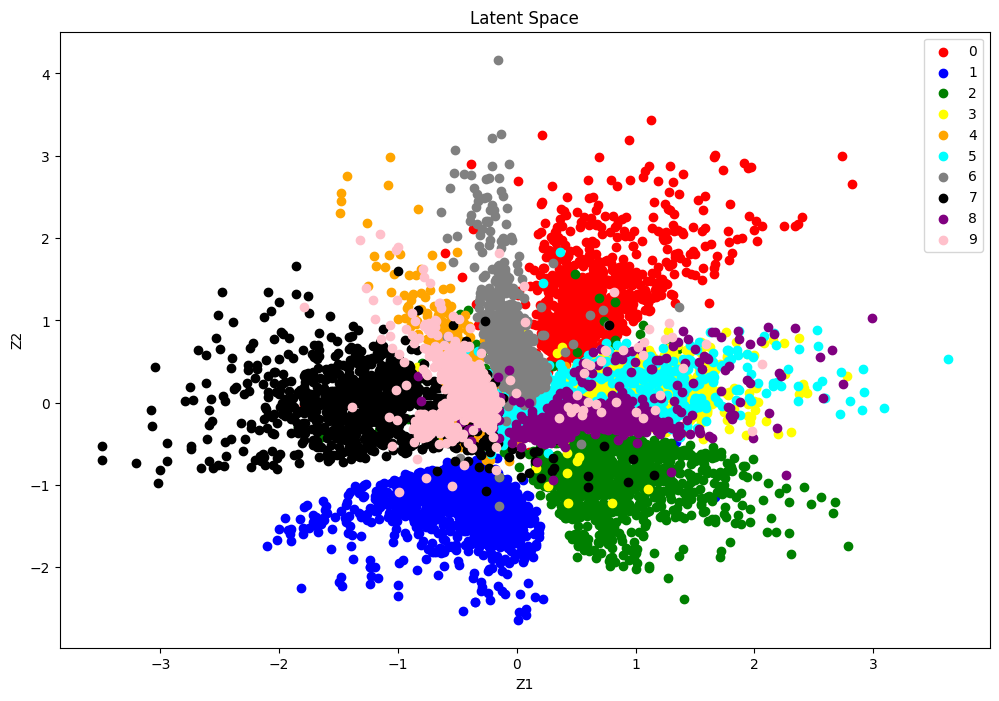

In [21]:
@torch.no_grad()
def show_vae_map_latent_space_distribution_visualization(
    model: VariationalAutoEncoder,
    val_dataset: Dataset,
    accelerator: str = 'cpu'
) -> None:
    """
    Displays the distribution of data in the VAE latent space.

    Args:
        model: The VAE model.
        val_dataset: Dataset used for the visualization.
        accelerator: The device for calculations ('cpu' or 'cuda').
    """
    COLORS = ['red', 'blue', 'green', 'yellow', 'orange', 'cyan', 'gray', 'black', 'purple', 'pink']
    model.eval()
    model.to(accelerator)

    zs = defaultdict(list)
    for i in tqdm(range(len(val_dataset))):
        img = val_dataset[i].to(accelerator)
        label = val_dataset.label(i)
        # Posterior mean mu only (no sampling) for a cleaner 2-D scatter
        output = model.forward(img.unsqueeze(0), sample=False)
        z = output['z_mean'][0]

        zs[label].append(z.detach().cpu())

    zs = {k: torch.stack(v) for k, v in zs.items()}
    zs = dict(sorted(zs.items()))
    plt.figure(figsize=(12, 8))
    for i, (label, z) in enumerate(zs.items()):
        z = z.numpy()
        plt.scatter(z[:, 0], z[:, 1], color=COLORS[i], label=str(label))

    plt.legend()
    plt.title('Latent Space')
    plt.xlabel('Z1')
    plt.ylabel('Z2')
    plt.show()

show_vae_map_latent_space_distribution_visualization(
    model=vae,
    val_dataset=UnsupervisedMNIST(train=False),
    accelerator=ACCELERATOR
)


##### Generating new samples (sampling from the prior)

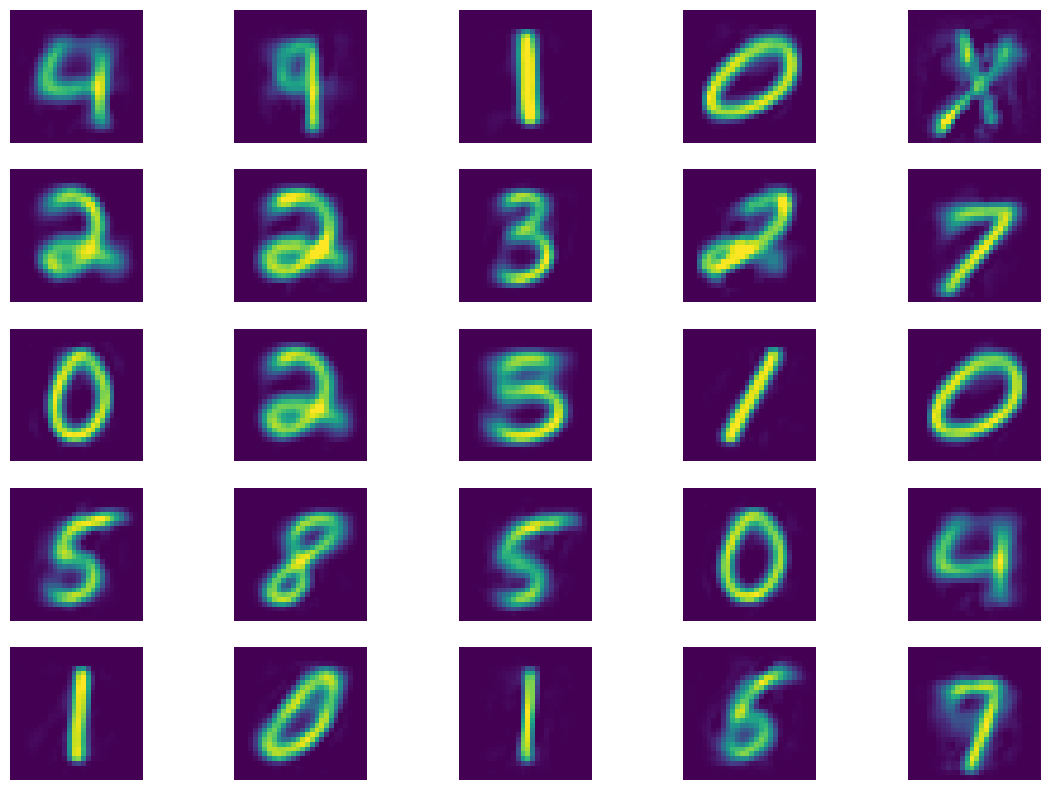

In [23]:
# Decode random z ~ N(0, I): tests what the generator learned (unconditional samples)
def visualize_vae_sampling_from_prior(
    model: VariationalAutoEncoder,
    postprocess_image: Callable[[torch.Tensor], np.ndarray],
    accelerator: str = 'cpu'
) -> None:
    """
    Grid of samples drawn from the prior through the decoder.

    Args:
        model: The VAE model.
        postprocess_image: Transforms raw model output to an image.
        accelerator: The device for calculations ('cpu' or 'cuda').
    """
    model.to(accelerator)
    model.eval()

    _, axs = plt.subplots(figsize=(14, 10), nrows=5, ncols=5)
    for i in range(5):
        for j in range(5):
            ax = axs[i][j]
            img = model.sample_from_prior()
            img = postprocess_image(img)
            show_image(img, ax=ax)
    plt.show()

visualize_vae_sampling_from_prior(
    model=vae,
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


##### Generating new samples similar to the given one (sampling from the posterior)

print::::minist <class 'torchvision.datasets.mnist.MNIST'>


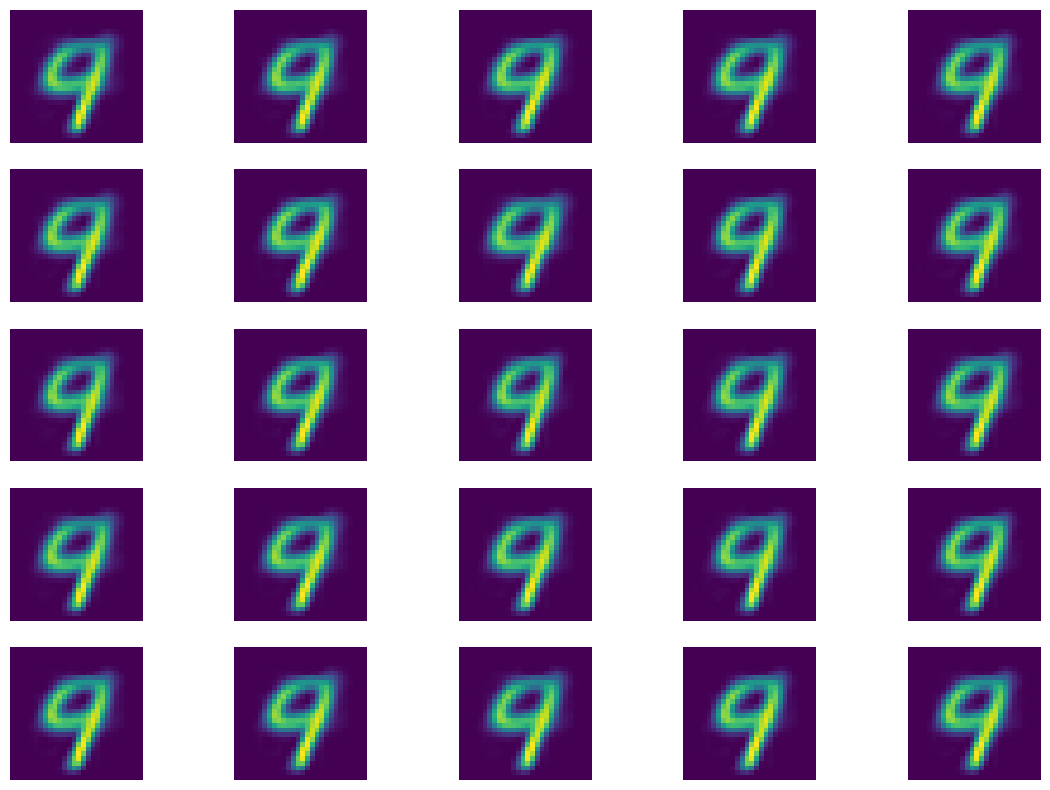

In [30]:
# Multiple decodes from q(z|x) for one fixed image — diversity from stochastic latent
def visualize_vae_sampling_from_posterior(
    model: VariationalAutoEncoder,
    evidence: torch.Tensor,
    postprocess_image: Callable[[torch.Tensor], np.ndarray],
    accelerator: str = 'cpu'
) -> None:
    """
    Many samples from the approximate posterior for a single input (same evidence, different z).

    Args:
        model: The VAE model.
        evidence: One image tensor (C, H, W) used as conditioning.
        postprocess_image: Transforms raw model output to an image.
        accelerator: The device for calculations ('cpu' or 'cuda').
    """
    model.to(accelerator)
    model.eval()
    evidence = evidence.to(accelerator)

    _, axs = plt.subplots(figsize=(14, 10), nrows=5, ncols=5)
    for i in range(5):
        for j in range(5):
            ax = axs[i][j]
            img = model.sample_from_posterior(evidence)
            img = postprocess_image(img)
            show_image(img, ax=ax)
    plt.show()

visualize_vae_sampling_from_posterior(
    model=vae,
    evidence=UnsupervisedMNIST(train=False)[7864],
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


##### Interpolation over the latent space

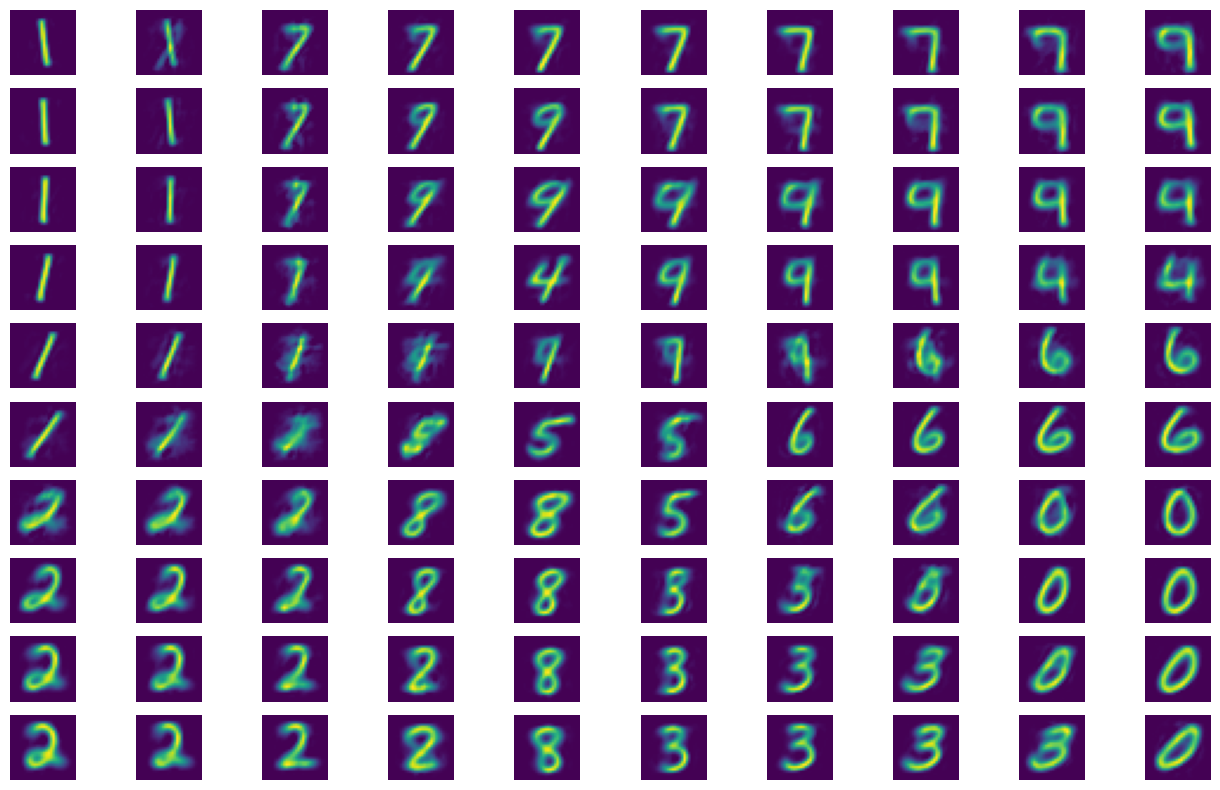

In [29]:
# Walk the 2-D latent square [-1,1]^2 through the decoder — local geometry of the learned manifold
def vizualize_vae_interpolation(
    model: VariationalAutoEncoder,
    postprocess_image: Callable[[torch.Tensor], np.ndarray],
    accelerator: str = 'cpu'
) -> None:
    model.to(accelerator)
    model.eval()

    _, axs = plt.subplots(figsize=(16, 10), nrows=10, ncols=10)
    for i in range(10):
        for j in range(10):
            ax = axs[i][j]
            z = torch.tensor([-1 + 2 * (i / 10), -1 + 2 * (j / 10)], dtype=torch.float32)
            z = z.to(accelerator)
            img = model._decoder(z)
            img = postprocess_image(img)
            show_image(img, ax=ax)
    plt.show()

vizualize_vae_interpolation(
    model=vae,
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


### Training VAE on the Fashion MNIST dataset

In [ ]:
# Same MLP VAE architecture on Fashion-MNIST (labels still only for optional viz)
fashion_vae = MLPVariationalAutoEncoder()
history = train_variational_autoencoder(
    model=fashion_vae,
    train_dataset=UnsupervisedMNIST(train=True, fashion=True),
    val_dataset=UnsupervisedMNIST(train=False, fashion=True),
    accelerator=ACCELERATOR
)
show_vae_training_history(history)


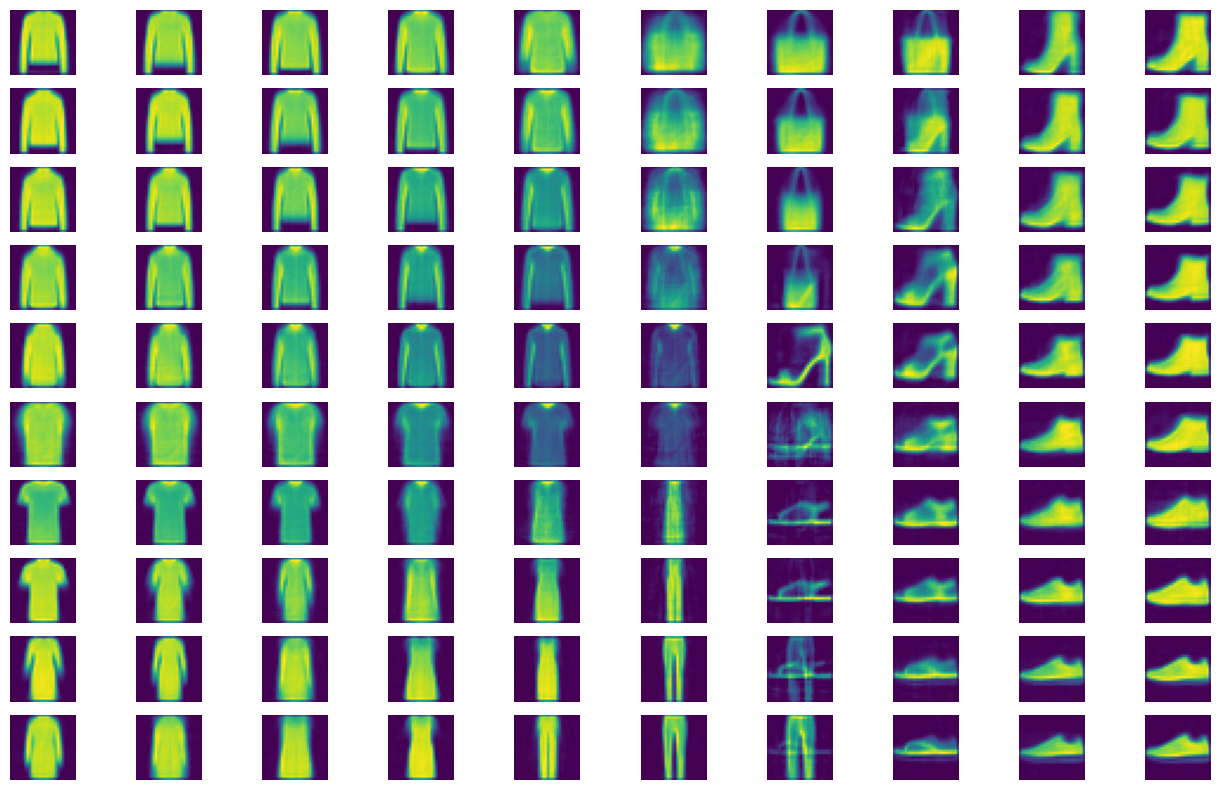

In [33]:
# Latent space walk for Fashion-MNIST VAE
vizualize_vae_interpolation(
    model=fashion_vae,
    postprocess_image=UnsupervisedMNIST.postprocess_image,
    accelerator=ACCELERATOR
)


### Generating images on Cifar10 with VAE

**Warning**: This section might be more complex compared to previous ones.

In [34]:
# --- CIFAR-10: per-channel mean/std (typical torchvision values) ---
CIFAR10_MEAN = torch.tensor([0.491 , 0.482, 0.447], dtype=torch.float32)
CIFAR10_STD = torch.tensor([0.202, 0.199 , 0.201], dtype=torch.float32)

def cifar10_standardize_transform(x: torch.Tensor) -> torch.Tensor:
    """
    Standardizes a given tensor using the precomputed CIFAR10 mean and standard deviation.

    Args:
        x: Input tensor to standardize.

    Returns:
        Standardized tensor.
    """
    # Per-pixel channel stats require HxWxC layout during subtraction
    x = torch.permute(x, (1, 2, 0))  # CxHxW -> HxWxC
    x = (x - CIFAR10_MEAN) / CIFAR10_STD
    x = torch.permute(x, (2, 0, 1))  # HxWxC -> CxHxW
    return x


def cifar10_standardize_inverse(x: torch.Tensor) -> torch.Tensor:
    """
    Reverses the standardization on a tensor using the precomputed CIFAR10 mean and standard deviation.

    Args:
        x: Input tensor to de-standardize.

    Returns:
        De-standardized tensor.
    """
    x = torch.permute(x, (1, 2, 0))  # CxHxW -> HxWxC
    x = x * CIFAR10_STD + CIFAR10_MEAN
    x = torch.permute(x, (2, 0, 1))  # HxWxC -> CxHxW
    return x


class UnsupervisedCIFAR10(Dataset):
    """
    Same pattern as UnsupervisedMNIST: only images for training, labels for plotting.
    """
    def __init__(self, train: bool = True, fashion: bool = False):
        """
        Initializes the dataset object, downloads the dataset and prepares the transform.

        Args:
            train: Whether to load the training split (True) or the test split (False).
        """
        self._cifar10 = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=train, download=True)
        self._to_tensor = transforms.ToTensor()

    def __getitem__(self, i: int) -> Tuple[torch.Tensor, torch.Tensor]:
        raw_img, _ = self._cifar10[i]  # unsupervised: ignore label here
        img = self._to_tensor(raw_img)
        return cifar10_standardize_transform(img)

    def __len__(self) -> int:
        return len(self._cifar10)

    def label(self, i: int) -> int:
        """
        Returns the label of an image in the dataset at a given index.
        This is only required for the future visualizations.

        Args:
            i: The index of the image for which to return the label.

        Returns:
            The label of the image at the given index.
        """
        return self._cifar10[i][1]

    @staticmethod
    def postprocess_image(img: torch.Tensor) -> np.ndarray:
        """
        Performs inverse operation to the data preprocessing. Used for model output inverse.

        Args:
            img: Raw img output

        Returns:
            Postprocessed image.
        """
        img = img.detach().cpu()
        img = cifar10_standardize_inverse(img)
        img = torch.clip(img, min=0.0, max=1.0)  # valid RGB range before uint8
        img = img * 255
        img = img.numpy().astype(np.uint8)
        img = np.transpose(img, (1, 2, 0))  # CHW -> HWC for imshow
        return img


cifar10_example = UnsupervisedCIFAR10(train=True)
cifar10_example[0].shape, cifar10_example.label(0)


100%|██████████| 170M/170M [00:05<00:00, 31.1MB/s]


(torch.Size([3, 32, 32]), 6)

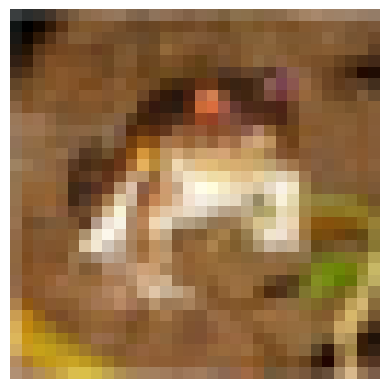

In [ ]:
# Quick sanity check: one CIFAR image after inverse preprocessing
show_image(UnsupervisedCIFAR10.postprocess_image(cifar10_example[0]))


Cifar-10 is more complex than MNIST and hence it won't be enough to just use a MLPVAE model. In this section we also implement the CNNVAE.
It is assumed that reader understand how CNN and TransposeCNN layers work.

TransposeCNN explanation can be found [here](https://d2l.ai/chapter_computer-vision/transposed-conv.html).

In [35]:
IntTuple = Union[Tuple[int], int]  # kernel/stride may be int or tuple

class CNNBlock(nn.Module):
    """Conv2d + BatchNorm + LeakyReLU — encoder building block (downsampling when stride>1)."""
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: IntTuple,
        stride: IntTuple = 1,
        padding: Union[int, str] = 'same',
        **kwargs
    ):
        """
        Convolutional 2D layer combiner with 2d batch norm

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels
            kernel_size: Kernel size
            stride: Stride
            padding: Padding
            **kwargs:
        """
        super().__init__()
        self._conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False, **kwargs)
        self._batchnorm = nn.BatchNorm2d(out_channels)
        self._lrelu = nn.LeakyReLU(0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._batchnorm(self._conv(x))
        x = self._lrelu(x)
        return x


class TransposeCNNBlock(nn.Module):
    """ConvTranspose2d + BatchNorm + LeakyReLU — decoder upsampling block."""
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: IntTuple,
        stride: IntTuple = 2,
        padding: int = 0,
        output_padding: int = 0,
        **kwargs
    ):
        """
        Transpose convolutional 2D layer combined with 2D batch norm

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels
            kernel_size: Kernel size
            stride: Stride
            padding: Padding
            output_padding: Output padding
        """
        super().__init__()
        self._conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, output_padding, bias=False, **kwargs)
        self._batchnorm = nn.BatchNorm2d(out_channels)
        self._lrelu = nn.LeakyReLU(0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._batchnorm(self._conv(x))
        x = self._lrelu(x)
        return x


class CNNVariationalAutoEncoder(VariationalAutoEncoder):
    """
    Convolutional VAE for 32x32 RGB: spatial encoder, vector latent, transposed conv decoder.
    """
    def __init__(self, input_shape: Tuple[int, int, int] = (3, 32, 32), in_channels: int = 3, latent_dim: int = 128):
        """
        Args:
            input_shape: Input image shape (default is for Cifar10)
            in_channels: Number of input channels
            latent_dim: Latent dimension
        """
        image_flat_size = input_shape[0] * input_shape[1] * input_shape[2]
        # Spatial size after two stride-2 blocks: H,W -> H/4,W/4 with 128 channels
        encoder_shape = (128, input_shape[1] // 4, input_shape[2] // 4)
        encoder_flat_size = input_shape[1] * input_shape[2] // 16 * 128

        encoder = nn.Sequential(
            CNNBlock(in_channels, 32, 3),
            CNNBlock(32, 64, 3, stride=2, padding=1),  # 32 -> 16
            CNNBlock(64, 64, 3),
            CNNBlock(64, 128, 3, stride=2, padding=1),  # 16 -> 8
            nn.Flatten(start_dim=-3),
            nn.Linear(encoder_flat_size, 2 * latent_dim),  # mu and log-var for q(z|x)
        )

        decoder = nn.Sequential(
            nn.Linear(latent_dim, encoder_flat_size),
            nn.ReLU(),
            nn.Unflatten(-1, encoder_shape),
            TransposeCNNBlock(128, 64, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            CNNBlock(64, 64, 3),
            TransposeCNNBlock(64, 32, 3, stride=2, padding=1, output_padding=1),  # 16 -> 32
            CNNBlock(32, 32, 3),
            nn.Conv2d(32, 3, 1)  # 1x1 conv: logits / means of RGB channels
        )

        super().__init__(encoder=encoder, decoder=decoder)
        self._latent_dim = latent_dim

cnnvae_example = CNNVariationalAutoEncoder()
cnnvae_example.show_encoder_transforms(torch.randn(2, 3, 32, 32, dtype=torch.float32))
cnnvae_example.show_decoder_transforms(torch.randn(2, 128, dtype=torch.float32))


---Encoder transforms---
Input shape: torch.Size([2, 3, 32, 32])
[1] name=CNNBlock, shape=torch.Size([2, 32, 32, 32])
[2] name=CNNBlock, shape=torch.Size([2, 64, 16, 16])
[3] name=CNNBlock, shape=torch.Size([2, 64, 16, 16])
[4] name=CNNBlock, shape=torch.Size([2, 128, 8, 8])
[5] name=Flatten, shape=torch.Size([2, 8192])
[6] name=Linear, shape=torch.Size([2, 256])
---Decoder transforms---
[0] Input shape: torch.Size([2, 128])
[1] name=Linear, shape=torch.Size([2, 8192])
[2] name=ReLU, shape=torch.Size([2, 8192])
[3] name=Unflatten, shape=torch.Size([2, 128, 8, 8])
[4] name=TransposeCNNBlock, shape=torch.Size([2, 64, 16, 16])
[5] name=CNNBlock, shape=torch.Size([2, 64, 16, 16])
[6] name=TransposeCNNBlock, shape=torch.Size([2, 32, 32, 32])
[7] name=CNNBlock, shape=torch.Size([2, 32, 32, 32])
[8] name=Conv2d, shape=torch.Size([2, 3, 32, 32])



In [ ]:
# Deeper latent (256) and smaller LR / longer schedule suit RGB CIFAR better than MNIST defaults
cifar10_vae = CNNVariationalAutoEncoder(latent_dim=256)
history = train_variational_autoencoder(
    model=cifar10_vae,
    train_dataset=UnsupervisedCIFAR10(train=True),
    val_dataset=UnsupervisedCIFAR10(train=False),
    accelerator=ACCELERATOR,
    base_learning_rate=1e-4,
    epochs=60,
    scheduler_step_size=40,
    batch_size=128,
    vae_noise=0.05
)
show_vae_training_history(history)


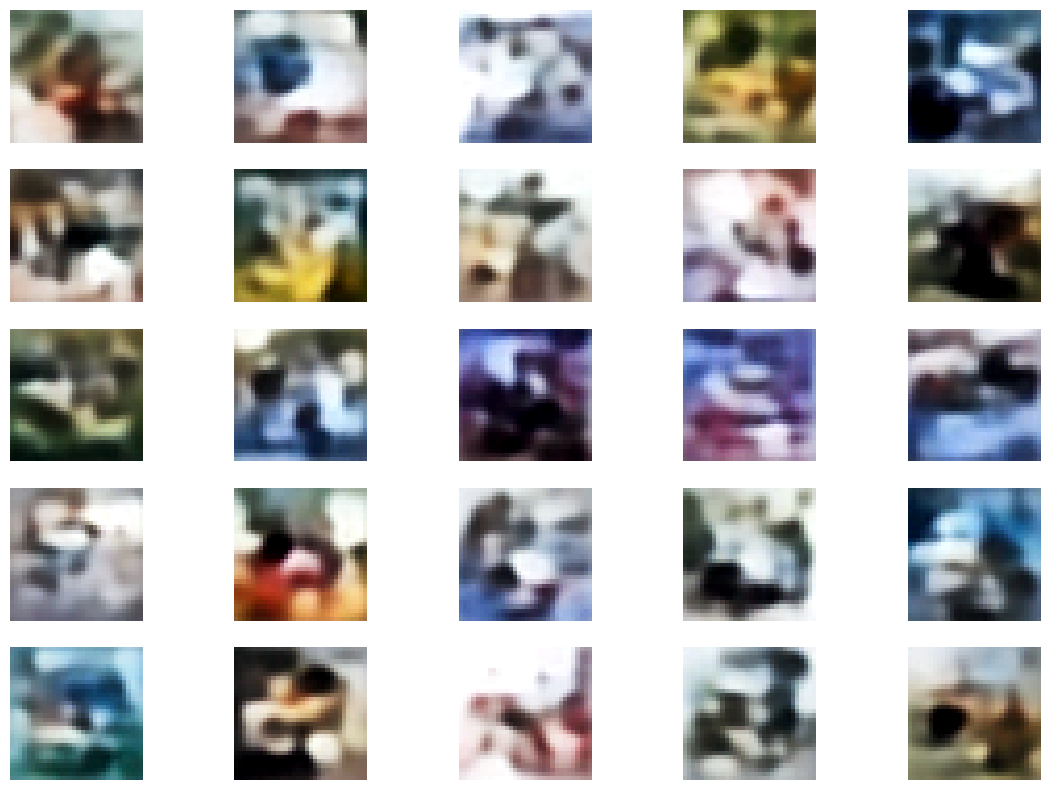

In [38]:
# Unconditional samples from learned prior (decoder only)
visualize_vae_sampling_from_prior(
    model=cifar10_vae,
    postprocess_image=UnsupervisedCIFAR10.postprocess_image,
    accelerator=ACCELERATOR
)


One of the drawback of the VAE models is that they tend to generate blurry images. The Cifar10 dataset is also very blurry and so it is bit hard to visually evaluate trained model on the prior sampling.